# **Notebook para Tesis**

Aqui hare el analisis y seleccion de caracteristicas

In [9]:
# Importar librerias necesarias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Interpolación
from scipy.interpolate import PchipInterpolator

## dotenv
from dotenv import load_dotenv
# Cargar variables de entorno
load_dotenv()

True

## **Lectura de Archivos**

In [10]:
from data_load import get_pulses_df

files_amount = 1 ## Número de archivos a cargar, 0 para cargar todos
data = get_pulses_df(os.getenv("pulses_csv_path"), files_amount) # type: ignore ## Cargar datos 

In [11]:
data

,Unnamed: 0,s_0,s_1,s_2,s_3,s_4,s_5,s_6,s_7,s_8,s_9,s_10,s_11,s_12,s_13,s_14,s_15
0,25,50,37,27,17,4,6,2,1,0,0,0,0,0,0,0,0
1,39,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,54,2,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,55,44,27,15,11,6,5,0,0,1,0,0,0,0,0,0,0
4,64,20,19,11,1,5,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959437,4666399,84,54,24,13,9,5,1,0,0,2,1,0,0,0,0,0
959438,4666402,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
959439,4666411,1,2,2,0,1,0,0,0,0,0,0,0,0,0,0,0
959440,4666412,4,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0


### **Muestreo de Datos**

In [12]:
# Muestro los datos
print(data.head())

   Unnamed: 0  s_0  s_1  s_2  s_3  s_4  s_5  s_6  s_7  s_8  s_9  s_10  s_11  \
0          25   50   37   27   17    4    6    2    1    0    0     0     0   
1          39    1    0    0    0    0    0    0    0    0    0     0     0   
2          54    2    3    0    0    0    0    0    0    0    0     0     0   
3          55   44   27   15   11    6    5    0    0    1    0     0     0   
4          64   20   19   11    1    5    0    0    0    0    0     0     0   

   s_12  s_13  s_14  s_15  
0     0     0     0     0  
1     0     0     0     0  
2     0     0     0     0  
3     0     0     0     0  
4     0     0     0     0  


## **Interpolación**

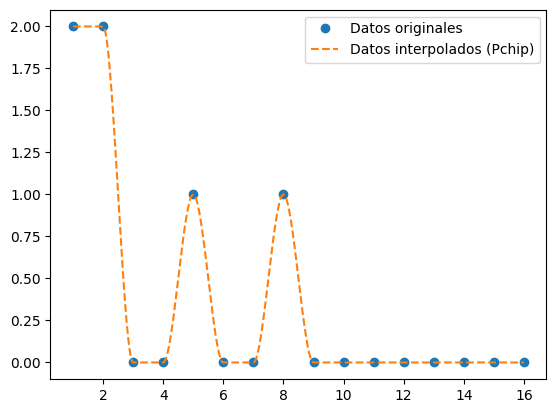

In [13]:
test = data.iloc[10, 1:].values # Tomo la segunda fila de data

x = np.arange(1, len(test)+1) 
y = test 

# cs = CubicSpline(x[mask], y[mask]) 
p = PchipInterpolator(x, y) 
xnew = np.linspace(1, len(test), num=1000)
ynew = p(xnew)

plt.plot(x, y, 'o', label='Datos originales') 
# plt.plot(xnew, cs(xnew), '-', label='Datos interpolados (Spline Cúbico)') #Conecta los puntos pero desvia de ellos un poco 
plt.plot(xnew, ynew, '--', label='Datos interpolados (Pchip)') #Conecta los puntos de manera suave
plt.legend()
plt.show()

In [31]:
from scipy.fft import fft, fftfreq

def interpolated_dominant_frequency(signal, x):
    """
    Calculates the dominant frequency of an interpolated signal using its time axis.

    :param signal: Array of the interpolated signal.
    :param x: Array of time values (same length as signal).
    :return: Dominant frequency in Hz.
    """
    N = len(signal)
    fs = 1 / np.mean(np.diff(x))
    freqs = fftfreq(N, d=1/fs)
    spectrum = np.abs(fft(signal))**2
    spectrum = spectrum[:N//2]
    freqs = freqs[:N//2]

    print(f"Sampling frequency: {fs} Hz, Number of points: {N}, spectrum length: {len(spectrum)}")

    idx = np.argmax(spectrum)
    plt.plot(freqs, spectrum)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Power Spectrum')
    plt.title('Power Spectrum of Interpolated Signal')
    plt.grid()
    plt.show()
    return freqs[idx]

Sampling frequency: 66.6 Hz, Number of points: 1000, spectrum length: 500


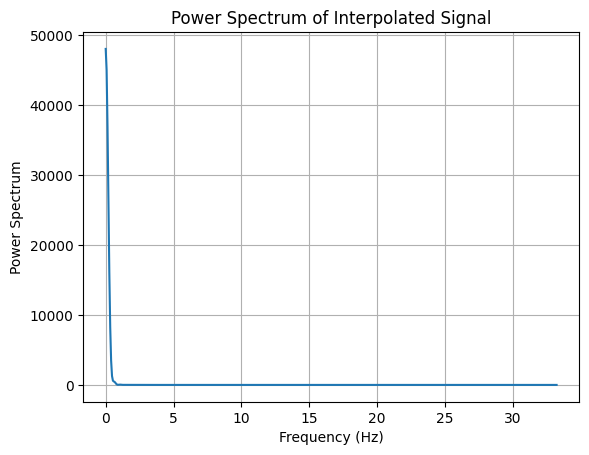

Dominant frequency: 0.0 Hz


In [32]:
## Ejemplo de uso de la función interpolated_dominant_frequency
dom_freq = interpolated_dominant_frequency(ynew, xnew)
print("Dominant frequency:", dom_freq, "Hz")

Pulse 1 - Dominant frequency: 0.0 Hz
Pulse 2 - Dominant frequency: 0.0 Hz
Pulse 3 - Dominant frequency: 0.0 Hz
Pulse 4 - Dominant frequency: 0.0 Hz
Pulse 5 - Dominant frequency: 0.0 Hz
Pulse 6 - Dominant frequency: 0.0 Hz
Pulse 7 - Dominant frequency: 0.0 Hz
Pulse 8 - Dominant frequency: 0.0 Hz
Pulse 9 - Dominant frequency: 0.0 Hz
Pulse 10 - Dominant frequency: 0.0 Hz
Pulse 11 - Dominant frequency: 0.0 Hz
Pulse 12 - Dominant frequency: 0.0 Hz
Pulse 13 - Dominant frequency: 0.0 Hz
Pulse 14 - Dominant frequency: 0.0 Hz
Pulse 15 - Dominant frequency: 0.0 Hz
Pulse 16 - Dominant frequency: 0.0 Hz
Pulse 17 - Dominant frequency: 0.0 Hz
Pulse 18 - Dominant frequency: 0.0 Hz
Pulse 19 - Dominant frequency: 0.0 Hz
Pulse 20 - Dominant frequency: 0.0 Hz
Pulse 21 - Dominant frequency: 0.0 Hz
Pulse 22 - Dominant frequency: 0.0 Hz
Pulse 23 - Dominant frequency: 0.0 Hz
Pulse 24 - Dominant frequency: 0.0 Hz
Pulse 25 - Dominant frequency: 0.0 Hz
Pulse 26 - Dominant frequency: 0.0 Hz
Pulse 27 - Dominant f

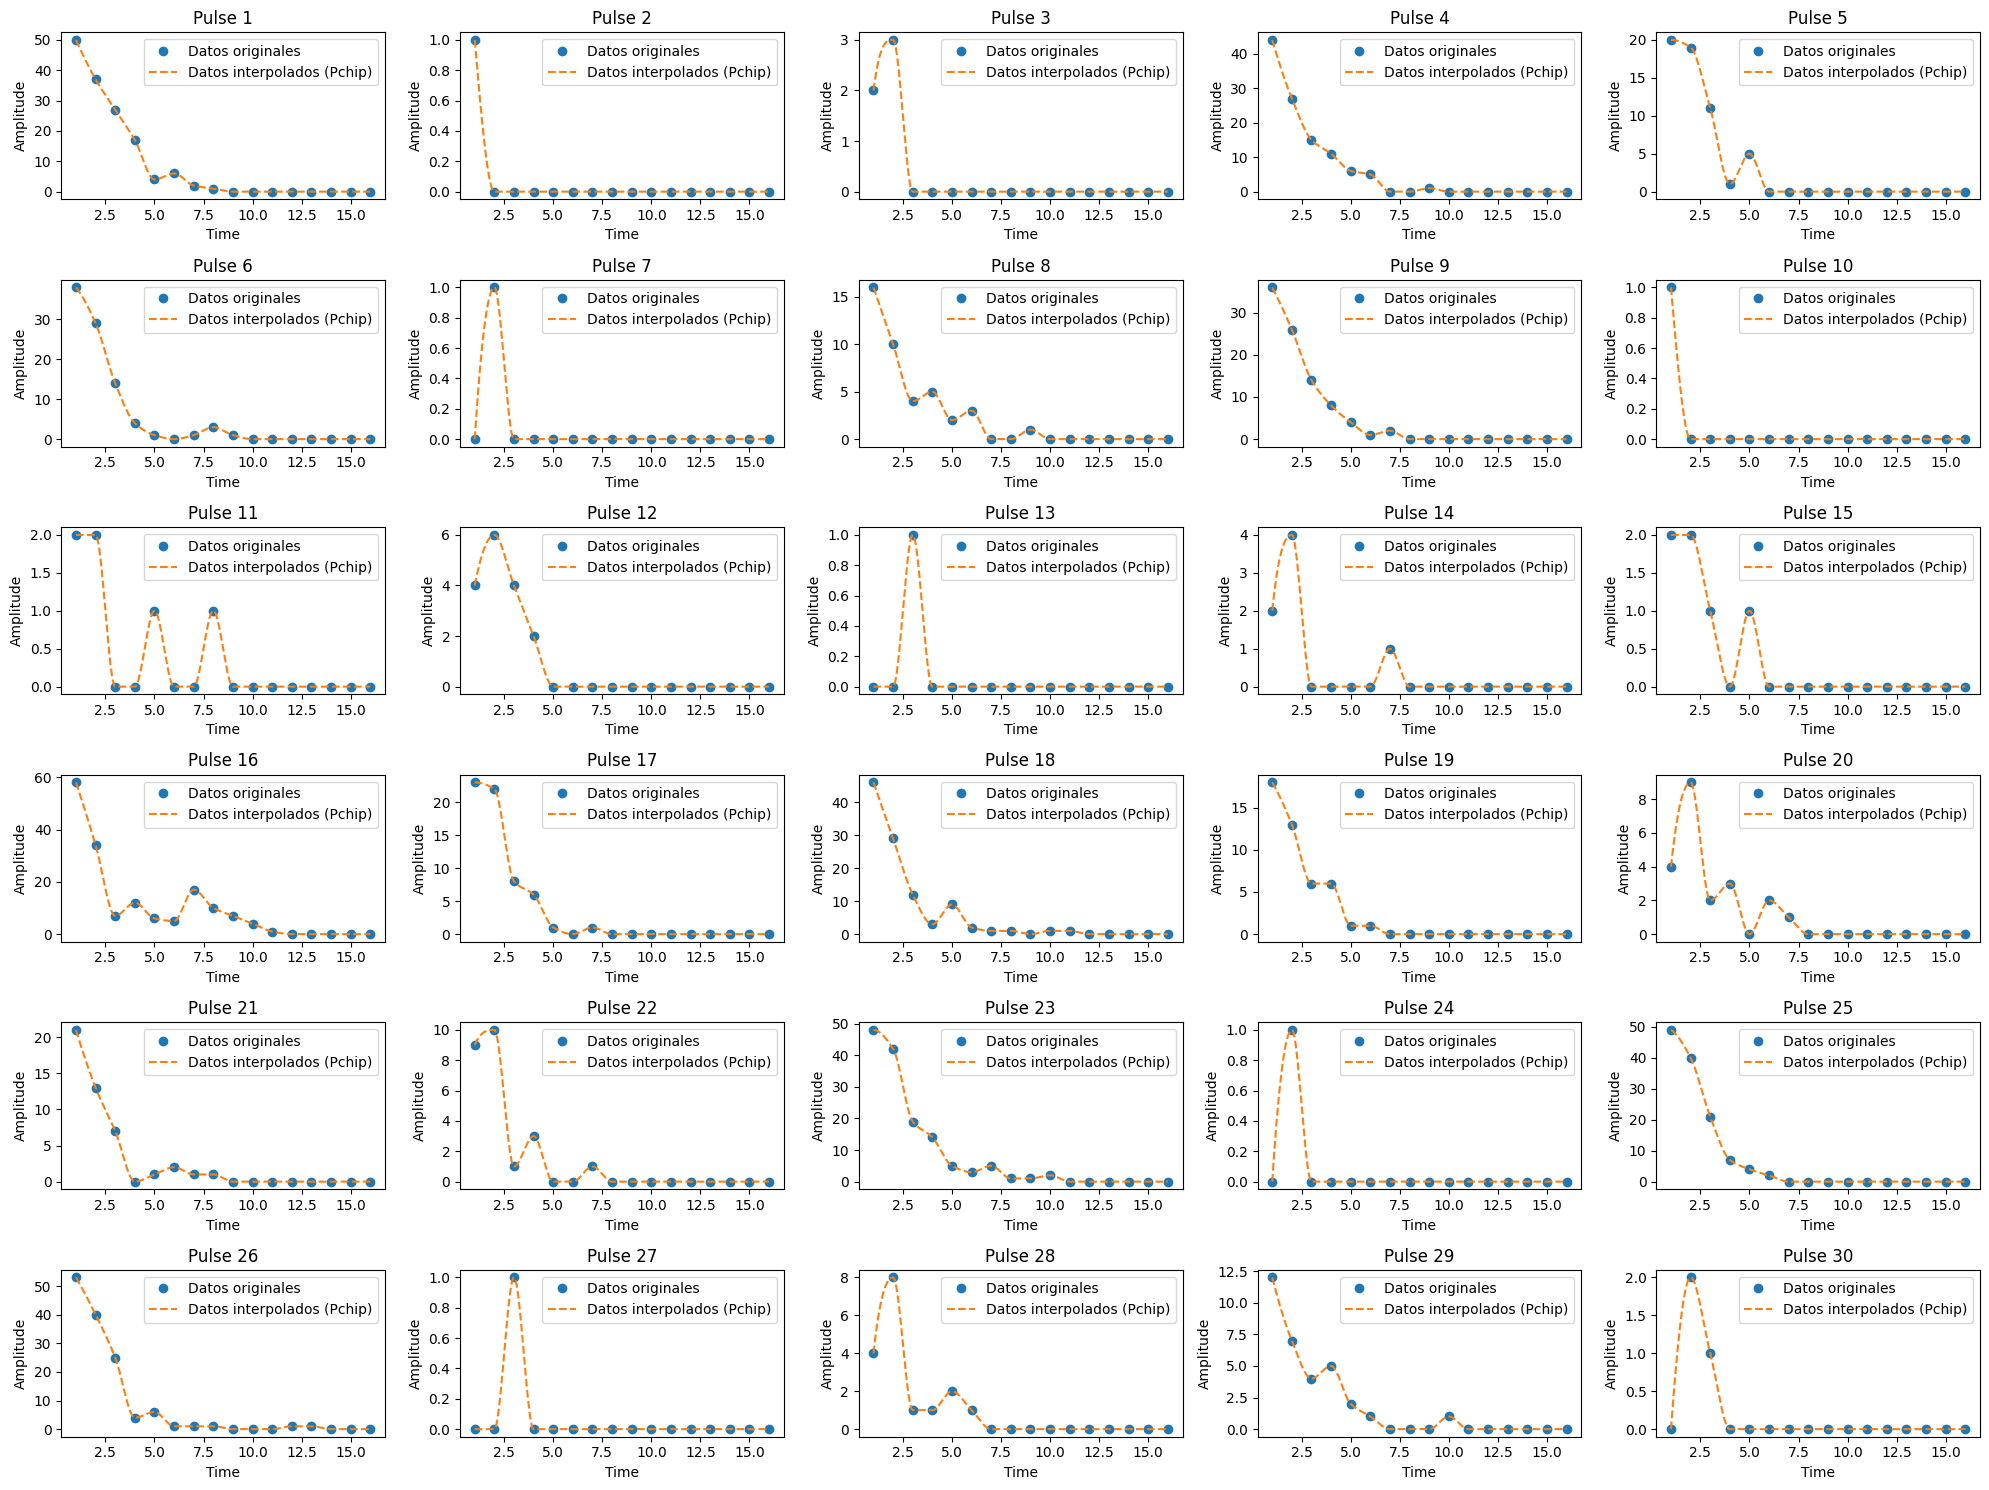

In [16]:
## interpolate first 30 pulses and calculate interpolated dominant frequency
for i in range(30):
    pulse = data.iloc[i, 1:].values
    x = np.arange(1, len(pulse)+1)
    p = PchipInterpolator(x, pulse)
    xnew = np.linspace(1, len(pulse), num=1000)
    ynew = p(xnew)
    dom_freq = interpolated_dominant_frequency(ynew, xnew)
    print(f"Pulse {i+1} - Dominant frequency: {dom_freq} Hz")
## plot 30 first pulses separately in grid
fig, axs = plt.subplots(6, 5, figsize=(20, 15))
for i in range(30):
    pulse = data.iloc[i, 1:].values
    x = np.arange(1, len(pulse)+1)
    p = PchipInterpolator(x, pulse)
    xnew = np.linspace(1, len(pulse), num=1000)
    ynew = p(xnew)

    axs[i//5, i%5].plot(x, pulse, 'o', label='Datos originales')
    axs[i//5, i%5].plot(xnew, ynew, '--', label='Datos interpolados (Pchip)')
    axs[i//5, i%5].set_title(f'Pulse {i+1}')
    axs[i//5, i%5].set_xlabel('Time')
    axs[i//5, i%5].set_ylabel('Amplitude')
    axs[i//5, i%5].legend()

plt.tight_layout()
plt.show()